In [ ]:
import numpy as np
import astropy.units as u
from astropy.coordinates import SkyCoord
from dustmaps.config import config
from dustmaps.sfd import SFDQuery
from dust_extinction.parameter_averages import G23

# dust map file, use your path
config['data_dir'] = '/Users/kaiwenzhang/PycharmProjects/pythonProject/ASTR5160/tasks/week3'


In [ ]:
# E(B-V) for the sightline
c = SkyCoord('06h02m11.70s', '+28.47278', unit=('hourangle', 'deg'))
ebv_sf11 = 0.86 * float(SFDQuery()(c))
# wavelength MUST be observed-frame (Angstrom)
wavelength = np.arange(4000, 8000, 1)
A_lambda = G23(Rv=3.1)(wavelength * u.AA) * (3.1 * ebv_sf11)   # mag
data = np.stack([wavelength, np.power(10.0, 0.4 * A_lambda)], axis=1)
np.savetxt('A_lambda.txt', data) # scale the error array too

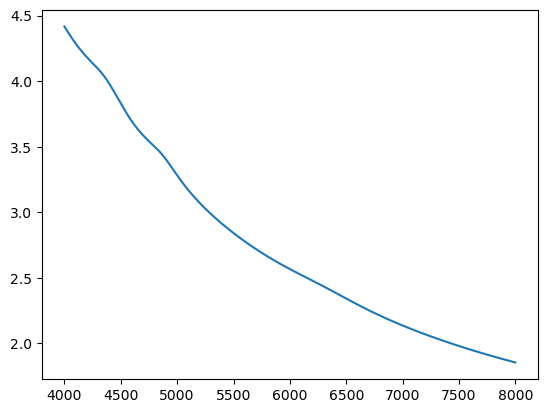

In [15]:
from matplotlib import pyplot as plt
plt.plot(wavelength, np.power(10.0, 0.4 * A_lambda))
plt.show()